# Examen de Primer Bimestre - Sistema de Recuperación de Información

**Materia:** ICCD753 Recuperación de Información  
**Periodo:** 2026-A  

## Objetivo

Implementar un sistema de recuperación de información que indexe documentos textuales mediante embeddings y recupere los documentos más relevantes para una consulta utilizando similitud coseno.

El sistema incluye:

- carga del corpus;
- selección de campos textuales;
- preprocesamiento;
- generación de embeddings;
- procesamiento de consultas;
- recuperación mediante similitud coseno;
- resultados Top-k para las 8 consultas obligatorias;
- tabla resumen general.

## Dependencias e imports

In [30]:
# imports

!pip install -q kagglehub sentence-transformers scikit-learn pandas numpy matplotlib

import os
import logging
import warnings

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TQDM_DISABLE"] = "1"

warnings.filterwarnings("ignore")

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

import re
import string

import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_columns", 100)

## Descargar dataset desde Kaggle

In [31]:
DATASET_NAME = "stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset"

path = kagglehub.dataset_download(DATASET_NAME)

print("Path to dataset files:", path)
print("\nArchivos encontrados:")

for file in os.listdir(path):
    print("-", file)

Path to dataset files: /kaggle/input/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset

Archivos encontrados:
- rotten_tomatoes_movies.csv
- rotten_tomatoes_critic_reviews.csv


## Cargar archivos de películas y reseñas

In [32]:
csv_files = [file for file in os.listdir(path) if file.lower().endswith(".csv")]

movies_file = None
reviews_file = None

for file in csv_files:
    name = file.lower()
    
    if "movies" in name:
        movies_file = file
        
    if "critic_reviews" in name:
        reviews_file = file

if movies_file is None:
    raise FileNotFoundError("No se encontró el archivo de películas.")

if reviews_file is None:
    raise FileNotFoundError("No se encontró el archivo de reseñas.")

movies_df = pd.read_csv(os.path.join(path, movies_file))
reviews_df = pd.read_csv(os.path.join(path, reviews_file))

print("Películas:", movies_df.shape)
print("Reseñas:", reviews_df.shape)

display(movies_df.head())
display(reviews_df.head())

Películas: (17712, 22)
Reseñas: (1130017, 8)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. At a training ground for the children of deities, Percy learns to harness his divine powers...","Though it may seem like just another Harry Potter knockoff, Percy Jackson benefits from a strong supporting cast, a speedy plot, and plenty of fun with Greek mythology.",PG,"Action & Adventure, Comedy, Drama, Science Fiction & Fantasy",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Daddario, Jake Abel, Sean Bean, Pierce Brosnan, Steve Coogan, Rosario Dawson, Melina Kanakaredes, Catherine Keener, Kevin Mckidd, Joe Pantoliano, Uma Thurman, Ray Winstone, Julian Richings, Bonita Fried...",2010-02-12,2015-11-25,119.0,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (Oliver Platt) are wealthy New Yorkers who prowl estate sales and make a tidy profit reselling items they bought cheaply. They buy the apartment next door and plan to remodel just as soon as its curren...,"Nicole Holofcener's newest might seem slight in places, but its rendering of complex characters in a conflicted economic landscape is varied, natural, and touching all the same.",R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, Rebecca Hall, Sarah Steele, Ann Morgan Guilbert, Kevin Corrigan, Lois Smith",2010-04-30,2012-09-04,90.0,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter falls hopelessly in love with the woman of his dreams, and even follows the girl and her new husband to their Mexican honeymoon resort. While his behavior seems sure to land him in trouble, out of th...","Blake Edwards' bawdy comedy may not score a perfect 10, but Dudley Moore's self-deprecating performance makes this midlife crisis persistently funny.",R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert Webber, Dee Wallace, Sam Jones III, Sam J. Jones, Brian Dennehy, Max Showalter, Rad Daly, Nedra Volz, James Noble, Virginia Kiser, John Hawker, Deborah Rush, Don Calfa, Walter George Alton, Annette Ma...",1979-10-05,2014-07-24,122.0,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),"Following the closing arguments in a murder trial, the 12 members of the jury must deliberate, with a guilty verdict meaning death for the accused, an inner-city teen. As the dozen men try to reach a unanimous decision while sequestered in a room...","Sidney Lumet's feature debut is a superbly written, dramatically effective courtroom thriller that rightfully stands as a modern classic.",NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G. Marshall, Jack Klugman, Edward Binns, Jack Warden, Henry Fonda, Joseph Sweeney, Ed Begley Sr., George Voskovec, Robert Webber, Rudy Bond, James A. Kelly, Billy Nelson, John Savoca",1957-04-13,2017-01-13,95.0,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Lukas) and his assistant Conseil (Peter Lorre), stranded in San Francisco by reports of a giant sea monster attacking ships in the Pacific Ocean, are invited to join an expedition to search

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy"
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instalment."
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,"Whether audiences will get behind The Lightning Thief is hard to predict. Overall, it's an entertaining introduction to a promising new world -- but will the consuming shadow of Potter be too big to break free of?"
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,"What's really lacking in The Lightning Thief is a genuine sense of wonder, the same thing that brings viewers back to Hogwarts over and over again."


## Revisar columnas disponibles

In [33]:
print("Columnas de películas:")
print(list(movies_df.columns))

print("\nColumnas de reseñas:")
print(list(reviews_df.columns))

Columnas de películas:
['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']

Columnas de reseñas:
['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


## Validar columnas necesarias

In [34]:
required_movies = ["rotten_tomatoes_link", "movie_title"]
required_reviews = ["rotten_tomatoes_link", "review_content"]

missing_movies = [col for col in required_movies if col not in movies_df.columns]
missing_reviews = [col for col in required_reviews if col not in reviews_df.columns]

if missing_movies:
    raise KeyError(f"Faltan columnas en películas: {missing_movies}")

if missing_reviews:
    raise KeyError(f"Faltan columnas en reseñas: {missing_reviews}")

print("Columnas necesarias disponibles.")

Columnas necesarias disponibles.


## Unir reseñas con datos de películas

In [35]:
# Unir los datos

df = reviews_df.merge(
    movies_df,
    on="rotten_tomatoes_link",
    how="left"
)

print("Corpus unido:", df.shape)
display(df.head())

Corpus unido: (1130017, 29)


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle,Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. At a training ground for the children of deities, Percy learns to harness his divine powers...","Though it may seem like just another Harry Potter knockoff, Percy Jackson benefits from a strong supporting cast, a speedy plot, and plenty of fun with Greek mythology.",PG,"Action & Adventure, Comedy, Drama, Science Fiction & Fantasy",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Daddario, Jake Abel, Sean Bean, Pierce Brosnan, Steve Coogan, Rosario Dawson, Melina Kanakaredes, Catherine Keener, Kevin Mckidd, Joe Pantoliano, Uma Thurman, Ray Winstone, Julian Richings, Bonita Fried...",2010-02-12,2015-11-25,119.0,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. At a training ground for the children of deities, Percy learns to harness his divine powers...","Though it may seem like just another Harry Potter knockoff, Percy Jackson benefits from a strong supporting cast, a speedy plot, and plenty of fun with Greek mythology.",PG,"Action & Adventure, Comedy, Drama, Science Fiction & Fantasy",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Daddario, Jake Abel, Sean Bean, Pierce Brosnan, Steve Coogan, Rosario Dawson, Melina Kanakaredes, Catherine Keener, Kevin Mckidd, Joe Pantoliano, Uma Thurman, Ray Winstone, Julian Richings, Bonita Fried...",2010-02-12,2015-11-25,119.0,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instalment.",Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets a lot more complicated when he learns he's the son of the Greek god Poseidon. At a training ground for the children of deities, Percy learns to harness his divine powers...","Though it may seem like just another Harry Potter knockoff, Percy Jackson benefits from a strong supporting cast, a speedy plot, and plenty of fun with Greek mythology.",PG,"Action & Adventure, Comedy, Drama, Science Fiction & Fantasy",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Daddario, Jake Abel, Sean Bean, Pierce Brosnan, Steve Coogan, Rosario Dawson, Melina Kanakaredes, Catherine Keener, Kevin Mckidd, Joe Pantoliano, Uma Thurman, Ray Winstone, Julian Richings, Bonita Fried...",2010-02-12,2015-11-25,119.0,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
3,m/0814255,Ben 

## Armar el texto de cada documento

In [36]:
# Crear texto del documento

text_columns = [
    "movie_title",
    "movie_info",
    "critics_consensus",
    "review_content"
]

for col in text_columns:
    if col not in df.columns:
        df[col] = ""
    df[col] = df[col].fillna("").astype(str)

df["raw_document_text"] = (
    df["movie_title"] + ". " +
    df["movie_info"] + ". " +
    df["critics_consensus"] + ". " +
    df["review_content"]
)

df = df[df["raw_document_text"].str.strip() != ""].copy()
df = df.reset_index(drop=True)
df["doc_id"] = df.index

print("Documentos:", len(df))

display(df[["doc_id", "movie_title", "review_content"]].head())

Documentos: 1130017


,doc_id,movie_title,review_content
0,0,Percy Jackson & the Olympians: The Lightning Thief,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle
1,1,Percy Jackson & the Olympians: The Lightning Thief,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy"
2,2,Percy Jackson & the Olympians: The Lightning Thief,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instalment."
3,3,Percy Jackson & the Olympians: The Lightning Thief,"Whether audiences will get behind The Lightning Thief is hard to predict. Overall, it's an entertaining introduction to a promising new world -- but will the consuming shadow of Potter be too big to break free of?"
4,4,Percy Jackson & the Olympians: The Lightning Thief,"What's really lacking in The Lightning Thief is a genuine sense of wonder, the same thing that brings viewers back to Hogwarts over and over again."


## Limitacion del corpus 

In [37]:
max_documents = 30000

if len(df) > max_documents:
    df = df.sample(n=max_documents, random_state=42).reset_index(drop=True)
    df["doc_id"] = df.index

print("Documentos usados:", len(df))

Documentos usados: 30000


## Limpiar texto

In [38]:
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["processed_text"] = df["raw_document_text"].apply(clean_text)

display(df[["doc_id", "movie_title", "processed_text"]].head())

,doc_id,movie_title,processed_text
0,0,The Smurfs 2,the smurfs 2 hoping to harness the magical smurfessence evil wizard gargamel creates a pair of smurflike creatures called naughties however only a real smurf can give gargamel what he wants so he kidnaps smurfette to force her to cast a spell tha...
1,1,Lemony Snicket's A Series of Unfortunate Events,lemony snickets a series of unfortunate events after the three young baudelaire siblings are left orphaned by a fire in their mansion they are carted off to live with their distant relative count olaf jim carrey unfortunately olaf is a cruel sche...
2,2,The End of Violence,the end of violence producer mike max bill pullman has made a fortune through his gory action flicks but his own capture at the hands of some thugs causes him to reexamine his role in violent productions after escaping the crooks he hides out wit...
3,3,Birth of the Dragon,birth of the dragon young bruce lee is trying to make a name for himself while working as a martial arts instructor in 1964 san francisco when lee meets wong jack man he challenges the kung fu master to a noholdsbarred fight that became the stuff...
4,4,Paradise Hills,paradise hills young women must band together to escape from a seemingly idyllic island that holds a sinister secret its ambitious reach occasionally exceeds its grasp but paradise hills offers fans of thoughtful scifi a visually distinctive trea...


## Cargar modelo de embeddings

In [39]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"

with open(os.devnull, "w") as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
    model = SentenceTransformer(model_name)

print("Modelo cargado:", model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Modelo cargado: sentence-transformers/all-MiniLM-L6-v2


## Generar embeddings del corpus

In [40]:
texts = df["processed_text"].tolist()

doc_embeddings = model.encode(
    texts,
    show_progress_bar=False,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64
)

print("Embeddings:", doc_embeddings.shape)

Embeddings: (30000, 384)


## Búsqueda por similitud coseno

In [43]:
#Busqueda

def search(query, top_k=5):
    query_clean = clean_text(query)
    
    query_embedding = model.encode(
        [query_clean],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    results = df.iloc[top_indices].copy()
    results["Ranking"] = range(1, len(results) + 1)
    results["Similitud"] = scores[top_indices]
    results["Fragmento de texto"] = results["raw_document_text"].str[:300]
    
    results = results.rename(columns={
        "doc_id": "ID documento",
        "movie_title": "Título película"
    })
    
    return results[
        [
            "Ranking",
            "ID documento",
            "Título película",
            "Fragmento de texto",
            "Similitud"
        ]
    ]

## Consultas

In [44]:
queries = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

queries

{'Q1': 'science fiction movie with advanced technology',
 'Q2': 'romantic story with emotional relationships',
 'Q3': 'action movie with intense fight scenes',
 'Q4': 'horror film that creates fear and suspense',
 'Q5': 'visually impressive movie with weak storyline',
 'Q6': 'emotionally moving performance by the lead actor',
 'Q7': 'predictable plot but entertaining experience',
 'Q8': 'movie praised by critics but unpopular with audiences'}

## Resultados top-k

In [45]:
top_k = 5
all_results = {}

for qid, query in queries.items():
    print("=" * 100)
    print(qid, "-", query)
    print("=" * 100)
    
    result = search(query, top_k=top_k)
    all_results[qid] = result
    
    display(result)

Q1 - science fiction movie with advanced technology


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
15644,1,15644,Mystery Science Theater 3000: The Movie,Mystery Science Theater 3000: The Movie. Dr. Clayton Forrester (Trace Beaulieu) figures he can rule the world if he deadens his subjects' brains by making them endure terrible movies. Exploiting his access to nearby satellite-dwellers Mike Nelson...,0.503287
12029,2,12029,Kin,"Kin. While scavenging for copper wire, Detroit teenager Eli Solinski stumbles upon a high-tech gun that holds special powers. When his brother, Jimmy, lands in trouble with a local crime boss, the two siblings take the mysterious weapon and go on...",0.487900
18730,3,18730,Mystery Science Theater 3000: The Movie,Mystery Science Theater 3000: The Movie. Dr. Clayton Forrester (Trace Beaulieu) figures he can rule the world if he deadens his subjects' brains by making them endure terrible movies. Exploiting his access to nearby satellite-dwellers Mike Nelson...,0.480310
26652,4,26652,Side by Side,"Side by Side. Directors James Cameron, David Fincher, Martin Scorsese, Christopher Nolan and others discuss digital technology's impact on filmmaking.. Keanu Reeves proves a groovy guide through this informative exploration of how technology is t...",0.472601
7498,5,7498,TRON,"TRON. When talented computer engineer Kevin Flynn (Jeff Bridges) finds out that Ed Dillinger (David Warner), an executive at his company, has been stealing his work, he tries to hack into the system. However, Flynn is transported into the digital...",0.467513


Q2 - romantic story with emotional relationships


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
14649,1,14649,SoulMate,SoulMate. A woman's life is disrupted when a book is written about a childhood friendship.. . Derek Tsang's film transcends its potentially cloying premise to tell a story of friendship and love that's at once melancholy and very emotional.,0.539341
15253,2,15253,A Ghost Story,"A Ghost Story. A passionate young couple, unexpectedly separated by a shocking loss, discover an eternal connection and a love that is infinite.. A Ghost Story deftly manages its ambitious themes through an inventive, artful, and ultimately poign...",0.536330
8195,3,8195,A Ghost Story,"A Ghost Story. A passionate young couple, unexpectedly separated by a shocking loss, discover an eternal connection and a love that is infinite.. A Ghost Story deftly manages its ambitious themes through an inventive, artful, and ultimately poign...",0.532989
16082,4,16082,Marriage Story,"Marriage Story. A stage director and his actor wife struggle through a grueling divorce that pushes them to their limits.. Observing a splintering union with compassion and expansive grace, the powerfully acted Marriage Story ranks among writer-d...",0.514974
6767,5,6767,A Ghost Story,"A Ghost Story. A passionate young couple, unexpectedly separated by a shocking loss, discover an eternal connection and a love that is infinite.. A Ghost Story deftly manages its ambitious themes through an inventive, artful, and ultimately poign...",0.514311


Q3 - action movie with intense fight scenes


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
4032,1,4032,Take the Lead,"Take the Lead. When internationally renowned dancer Pierre Dulaine (Antonio Banderas) takes a teaching job in a New York City public school, he meets ridicule from the street-wise students, who scoff at the notion of ballroom dancing. Far from be...",0.502313
21053,2,21053,Take the Lead,"Take the Lead. When internationally renowned dancer Pierre Dulaine (Antonio Banderas) takes a teaching job in a New York City public school, he meets ridicule from the street-wise students, who scoff at the notion of ballroom dancing. Far from be...",0.500346
7155,3,7155,Take the Lead,"Take the Lead. When internationally renowned dancer Pierre Dulaine (Antonio Banderas) takes a teaching job in a New York City public school, he meets ridicule from the street-wise students, who scoff at the notion of ballroom dancing. Far from be...",0.488670
29693,4,29693,Take the Lead,"Take the Lead. When internationally renowned dancer Pierre Dulaine (Antonio Banderas) takes a teaching job in a New York City public school, he meets ridicule from the street-wise students, who scoff at the notion of ballroom dancing. Far from be...",0.486343
5484,5,5484,Man in the Chair,Man in the Chair. A surly relic (Christopher Plummer) of old Hollywood helps a teen (Michael Angarano) make a movie.. A committed performance from Christopher Plummer can't save Man in the Chair's troubled and cliched script.. A neorealist drama ...,0.478805


Q7 - predictable plot but entertaining experience


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
16546,1,16546,Killing Ground,Killing Ground. Sam and Ian take off on what they believe will be a peaceful camping trip. Their break turns into a battle for survival when they discover a bloody toddler wandering around in the bush and find that an incredibly disturbing crime ...,0.496796
12273,2,12273,You Should Have Left,"You Should Have Left. Strange events plague a couple and their young daughter when they rent a secluded countryside house that has a dark past.. You Should Have Left hints at a genuinely creepy experience, but never quite manages to distill its i...",0.494960
26478,3,26478,Cheap Thrills,"Cheap Thrills. A series of escalating bets pits recently reunited friends against each other.. Gleefully nasty and darkly hilarious, Cheap Thrills lives down to its title in the best possible way.. It's good cheap quickfire shock-horror genre thr...",0.491122
26397,4,26397,Entertainment,"Entertainment. An abrasive stand-up comic (Gregg Turkington) hits the road to perform a series of shows at seedy venues.. As brilliantly and uncomfortably confrontational as its protagonist, Entertainment is a boundary-blurring exercise in cinema...",0.490849
20394,5,20394,Escape From Tomorrow,"Escape From Tomorrow. Weird sights and events threaten a man's (Roy Abramsohn) sanity during a family trip to a big theme park.. Conceptually audacious but only intermittently successful in execution, Escape From Tomorrow is nonetheless visually ...",0.488695


Q8 - movie praised by critics but unpopular with audiences


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
20906,1,20906,Scary Movie,"Scary Movie. Defying the very notion of good taste, Scary Movie out-parodies the pop culture parodies with a no-holds barred assault on the most popular images and talked-about moments from recent films, television and commercials. The film boldl...",0.592098
948,2,948,Scary Movie,"Scary Movie. Defying the very notion of good taste, Scary Movie out-parodies the pop culture parodies with a no-holds barred assault on the most popular images and talked-about moments from recent films, television and commercials. The film boldl...",0.570781
9499,3,9499,Scary Movie,"Scary Movie. Defying the very notion of good taste, Scary Movie out-parodies the pop culture parodies with a no-holds barred assault on the most popular images and talked-about moments from recent films, television and commercials. The film boldl...",0.567352
1508,4,1508,Scary Movie,"Scary Movie. Defying the very notion of good taste, Scary Movie out-parodies the pop culture parodies with a no-holds barred assault on the most popular images and talked-about moments from recent films, television and commercials. The film boldl...",0.561608
9817,5,9817,Scary Movie,"Scary Movie. Defying the very notion of good taste, Scary Movie out-parodies the pop culture parodies with a no-holds barred assault on the most popular images and talked-about moments from recent films, television and commercials. The film boldl...",0.556261


## Resumen de los resultados

In [46]:
summary = []

for qid, query in queries.items():
    top_1 = all_results[qid].iloc[0]
    
    summary.append({
        "Consulta": f"{qid}: {query}",
        "Documento Top-1": top_1["ID documento"],
        "Título película": top_1["Título película"],
        "Similitud": top_1["Similitud"]
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Consulta,Documento Top-1,Título película,Similitud
0,Q1: science fiction movie with advanced technology,15644,Mystery Science Theater 3000: The Movie,0.503287
1,Q2: romantic story with emotional relationships,14649,SoulMate,0.539341
2,Q3: action movie with intense fight scenes,627,Brawl in Cell Block 99,0.611335
3,Q4: horror film that creates fear and suspense,3102,Nightmare Cinema,0.702203
4,Q5: visually impressive movie with weak storyline,11391,The Spectacular Now,0.570181
5,Q6: emotionally moving performance by the lead actor,4032,Take the Lead,0.502313
6,Q7: predictable plot but entertaining experience,16546,Killing Ground,0.496796
7,Q8: movie praised by critics but unpopular with audiences,20906,Scary Movie,0.592098


## Comprobacion final

In [47]:
assert len(queries) == 8
assert len(all_results) == 8
assert summary_df.shape[0] == 8
assert doc_embeddings.shape[0] == len(df)

for qid, result in all_results.items():
    assert result["Similitud"].is_monotonic_decreasing

print("Revisión final correcta.")

Revisión final correcta.


# Desafío de excelencia

## Desafio: Visualizar embeddings con PCA

,doc_id,movie_title,PCA 1,PCA 2
4136,4136,Spotlight,0.051773,-0.099654
24039,24039,Benji,-0.201449,0.081949
17862,17862,A Simple Plan,0.112265,0.112039
18806,18806,Man of Steel,0.257889,-0.085985
8706,8706,Nocturnal Animals,-0.193895,-0.245045
22945,22945,Sweeney Todd: The Demon Barber of Fleet Street,0.052414,0.107112
28739,28739,Adaptation,-0.025097,-0.087893
195,195,God Loves Uganda,0.109001,-0.144862
7953,7953,X-Men: First Class,0.170826,0.095993
25189,25189,Sanctum,0.235105,-0.226042


Varianza explicada PCA 1: 0.036740202
Varianza explicada PCA 2: 0.028082417
Varianza explicada total: 0.06482262


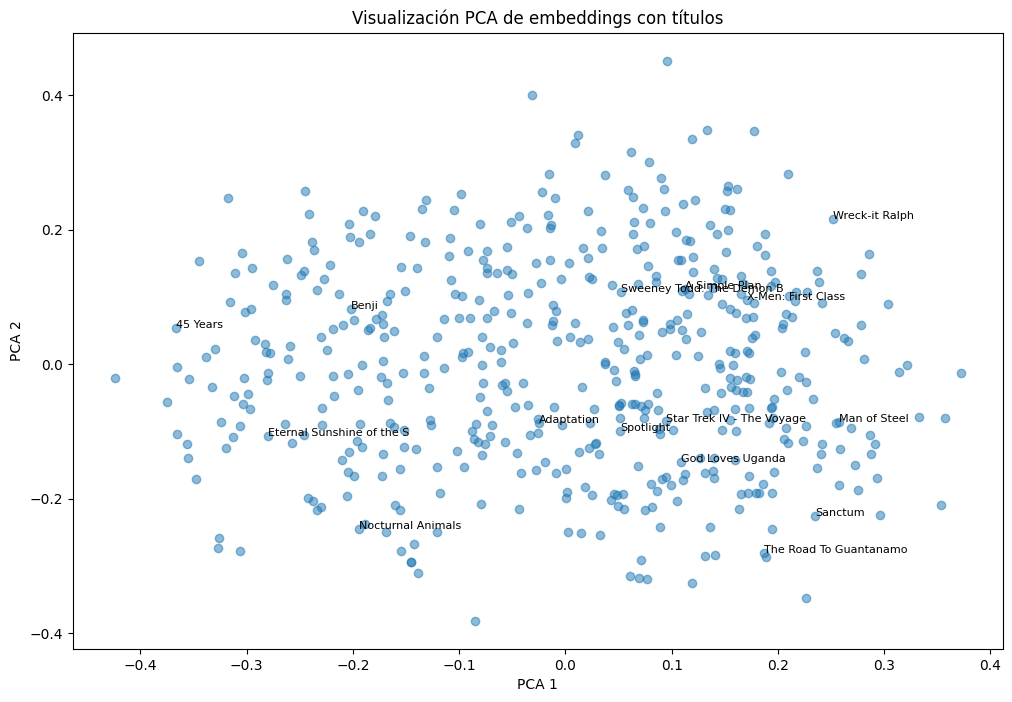

In [48]:
# PCA de embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sample_size = 500

n_sample = min(sample_size, len(df))

rng = np.random.default_rng(42)
sample_positions = rng.choice(len(df), size=n_sample, replace=False)

sample_df = df.iloc[sample_positions].copy()
sample_embeddings = doc_embeddings[sample_positions]

pca = PCA(n_components=2, random_state=42)
pca_points = pca.fit_transform(sample_embeddings)

sample_df["PCA 1"] = pca_points[:, 0]
sample_df["PCA 2"] = pca_points[:, 1]

pca_table = sample_df[[
    "doc_id",
    "movie_title",
    "PCA 1",
    "PCA 2"
]].copy()

display(pca_table.head(20))

print("Varianza explicada PCA 1:", pca.explained_variance_ratio_[0])
print("Varianza explicada PCA 2:", pca.explained_variance_ratio_[1])
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(12, 8))
plt.scatter(sample_df["PCA 1"], sample_df["PCA 2"], alpha=0.5)

for _, row in sample_df.head(15).iterrows():
    plt.text(
        row["PCA 1"],
        row["PCA 2"],
        str(row["movie_title"])[:25],
        fontsize=8
    )

plt.title("Visualización PCA de embeddings con títulos")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [49]:
# revisión PCA

assert "PCA 1" in sample_df.columns
assert "PCA 2" in sample_df.columns
assert pca_points.shape[1] == 2
assert len(sample_df) == n_sample

print("PCA ejecutado correctamente.")

PCA ejecutado correctamente.


## Conclusión

Se logró construir un sistema de recuperación de información usando el dataset de Rotten Tomatoes. El notebook carga los datos, selecciona campos textuales del corpus, arma el texto de cada documento y aplica un preprocesamiento básico antes de generar los embeddings.

La recuperación se realizó comparando el embedding de cada consulta con los embeddings de los documentos mediante similitud coseno. Se ejecutaron las ocho consultas indicadas en el enunciado y para cada una se muestran los resultados Top-k con ranking, identificador del documento, título de la película, fragmento de texto y similitud.

También se incluye una tabla resumen con el documento Top-1 de cada consulta. Como mejora adicional, se agregó una visualización con PCA sobre una muestra de embeddings para observar su distribución en dos dimensiones.